### Goal: Create a function that allows us to put in a coordinate, and figure out whether or not it's in the 27th Ward

**Why?**
Most Chicago city data (e.g. traffic data) is in coordinate form. At the same time, it's not always easy to tell where an incident is located and what Ward it's in. 

**How do we do this?**
We look at the ward map and see what ward each point corresponds to

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely import wkt

In [3]:
boundaries = pd.read_csv('Boundaries_-_Wards_(2023-)_20260622.csv').set_index('Ward')

In [4]:
our_ward = boundaries.loc[27]

In [5]:
our_ward_shape = our_ward['the_geom']
points_as_string = our_ward_shape[our_ward_shape.find("(((")+3:our_ward_shape.find(")))")]

points_list = []
for coord in points_as_string.split(','):
    x, y = [float(x) for x in coord.split(' ') if x]
    points_list.append((x, y))

points = np.asarray(points_list)

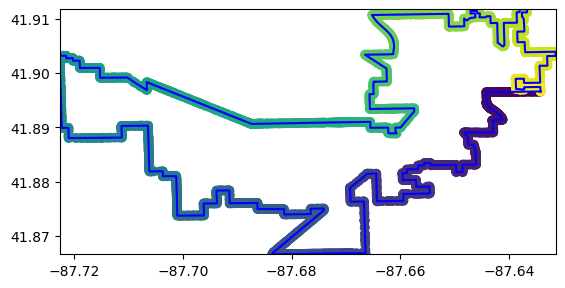

In [6]:
x, y = points[:,0], points[:,1]
x_closed = np.append(x, x[0])
y_closed = np.append(y, y[0])

plt.plot(x_closed, y_closed, 'b-')   # 'b-' = blue solid line
plt.scatter(x, y, c=range(len(x)), cmap='viridis')             # color = order
plt.xlim(np.min(x), np.max(x))        # x-axis from -1 to 3
plt.ylim(np.min(y), np.max(y))        # y-axis from -1 to 3
plt.gca().set_aspect('equal', adjustable="box")                     # keeps proportions correct
plt.show()

In [7]:
def ward_shape(ward_num):
    ward = boundaries.loc[ward_num]
    return wkt.loads(ward['the_geom'])

In [8]:
def inside_shape(shape, longitude, latitude):
    return shape.contains(Point(longitude, latitude))

In [9]:
def in_which_ward(longitude, latitude):
    inside = []
    # check all 50 wards
    for i in range(1, 51):
        ward = ward_shape(i)
        if inside_shape(ward, longitude, latitude):
            inside.append(i)

    return inside

In [10]:
# null point should be in no ward
in_which_ward(0, 0)

[]

In [11]:
# our office location!
in_which_ward(-87.6646864, 41.8895073)

[27]

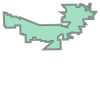

In [12]:
ward_shape(27)